# Matplotlib Integration

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chaobrain/saiunit/blob/master/docs/visualization/matplotlib_integration.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/chaobrain/saiunit/blob/master/docs/visualization/matplotlib_integration.ipynb)

saiunit integrates with Matplotlib so you can plot `Quantity` arrays directly.
The converter is registered automatically when saiunit is imported, so axis labels
show the correct unit name without manual formatting.

In [10]:
import matplotlib.pyplot as plt
import numpy as np

import saiunit as u

## Basic Plotting with Quantities

Pass `Quantity` arrays directly to `plt.plot()`. Matplotlib automatically extracts
the numeric values and labels axes with units.

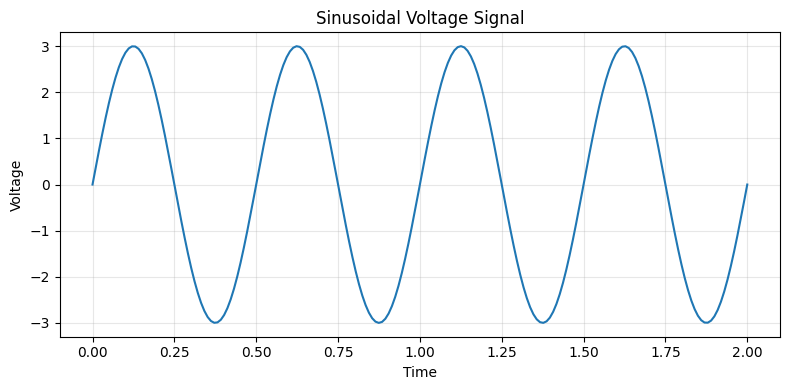

In [11]:
t = np.linspace(0.0, 2.0, 200) * u.second
voltage = (3.0 * u.volt) * np.sin(2.0 * np.pi * 2.0 * t.to_decimal(u.second))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, voltage)
ax.set_xlabel('Time')
ax.set_ylabel('Voltage')
ax.set_title('Sinusoidal Voltage Signal')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Plotting with Unit Conversion

Use `.to()` or `.in_unit()` to convert quantities to different units before plotting.

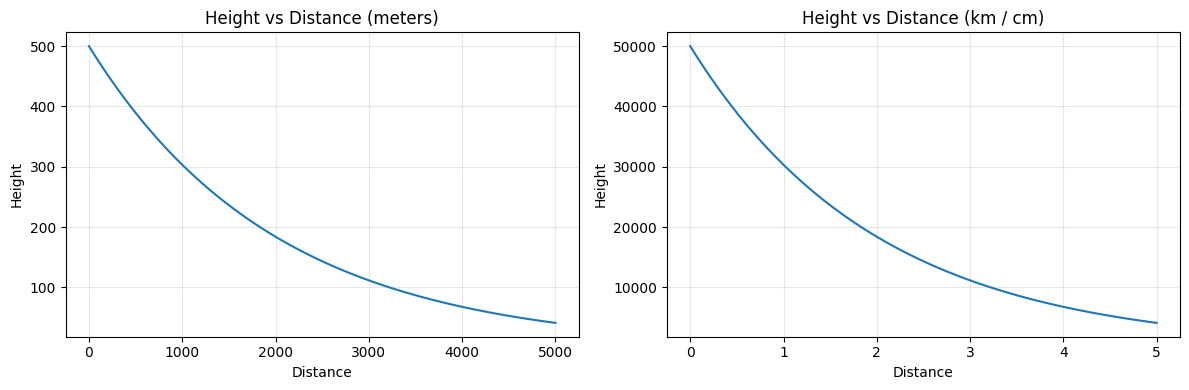

In [12]:
distance = np.linspace(0, 5000, 100) * u.meter
height = (500.0 * u.meter) * np.exp(-distance.to_decimal(u.meter) / 2000.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot in meters
ax1.plot(distance, height)
ax1.set_xlabel('Distance')
ax1.set_ylabel('Height')
ax1.set_title('Height vs Distance (meters)')
ax1.grid(alpha=0.3)

# Plot in kilometers
ax2.plot(distance.in_unit(u.kmeter), height.in_unit(u.cmeter))
ax2.set_xlabel('Distance')
ax2.set_ylabel('Height')
ax2.set_title('Height vs Distance (km / cm)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Multiple Signals with Different Units

Use subplots to show related physical quantities with their respective units.

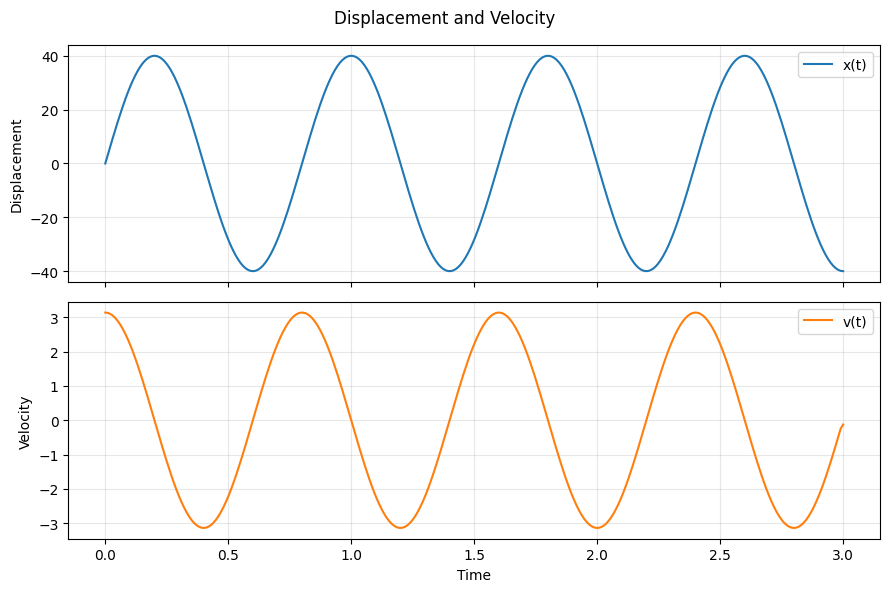

In [13]:
t = np.linspace(0.0, 3.0, 300) * u.second

# Displacement (cm)
x = (40.0 * u.cmeter) * np.sin(2.0 * np.pi * 1.25 * t.to_decimal(u.second))

# Velocity from numerical derivative
v = (
    np.gradient(x.to_decimal(u.meter), t.to_decimal(u.second))
    * (u.meter / u.second)
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(t, x, label='x(t)')
ax1.set_ylabel('Displacement')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(t, v, color='tab:orange', label='v(t)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Velocity')
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle('Displacement and Velocity')
plt.tight_layout()
plt.show()

## Quantity-Aware vs Plain Numeric

Compare plotting with `Quantity` (automatic labels) vs plain arrays (manual labels).

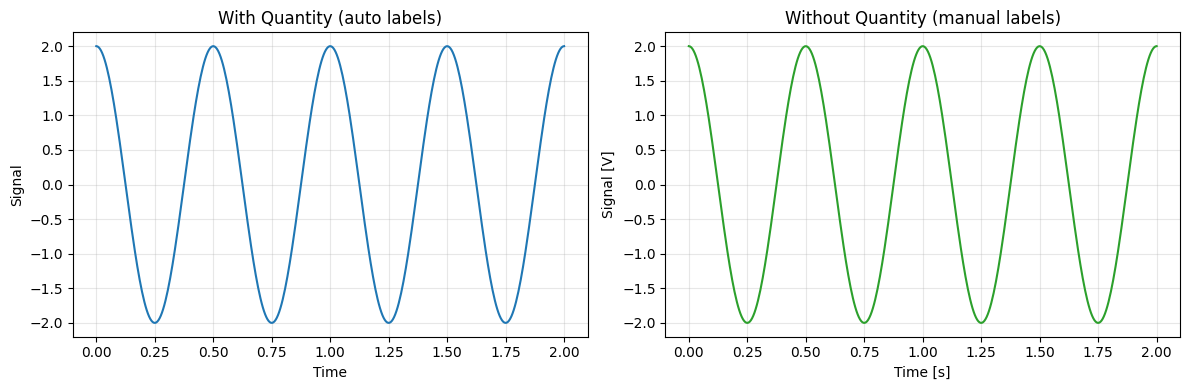

In [14]:
t_q = np.linspace(0.0, 2.0, 400) * u.second
y_q = (2.0 * u.volt) * np.cos(2.0 * np.pi * 2.0 * t_q.to_decimal(u.second))

t_plain = t_q.to_decimal(u.second)
y_plain = y_q.to_decimal(u.volt)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# With Quantity: unit labels added automatically
ax1.plot(t_q, y_q, color='tab:blue')
ax1.set_title('With Quantity (auto labels)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Signal')
ax1.grid(alpha=0.3)

# Plain arrays: you must add unit labels manually
ax2.plot(t_plain, y_plain, color='tab:green')
ax2.set_title('Without Quantity (manual labels)')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Signal [V]')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Scatter Plots

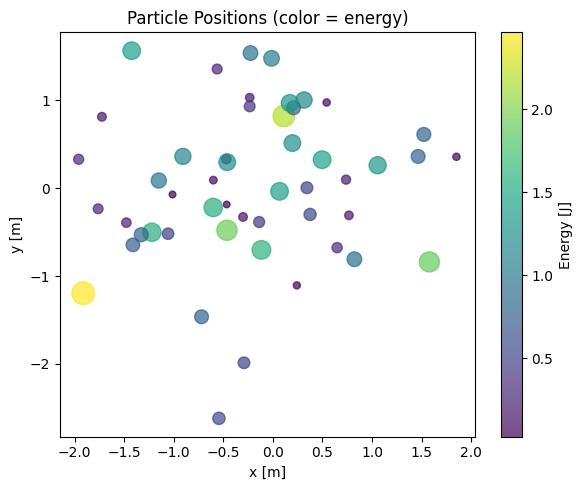

In [15]:
# Random particle positions and energies
np.random.seed(42)
x_pos = np.random.randn(50) * u.meter
y_pos = np.random.randn(50) * u.meter
energy = np.abs(np.random.randn(50)) * u.joule

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    x_pos.to_decimal(u.meter),
    y_pos.to_decimal(u.meter),
    c=energy.to_decimal(u.joule),
    s=energy.to_decimal(u.joule) * 100 + 20,
    alpha=0.7,
    cmap='viridis'
)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Particle Positions (color = energy)')
plt.colorbar(sc, label='Energy [J]')
plt.tight_layout()
plt.show()

## Bar Charts with Physical Quantities

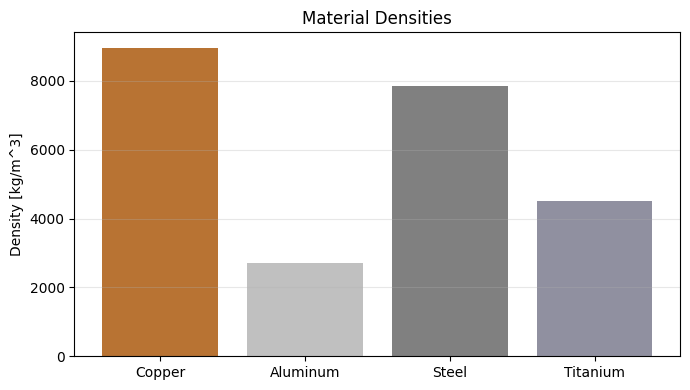

In [16]:
materials = ['Copper', 'Aluminum', 'Steel', 'Titanium']
densities = np.array([8960., 2700., 7850., 4507.]) * u.kilogram / u.meter ** 3

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(materials, densities.to_decimal(u.kilogram / u.meter ** 3),
              color=['#b87333', '#c0c0c0', '#808080', '#9090a0'])
ax.set_ylabel('Density [kg/m^3]')
ax.set_title('Material Densities')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Practical Example: RC Circuit Response

Plot the step response of an RC circuit, where all quantities carry physical units.

Time constant (tau): 0.001 s


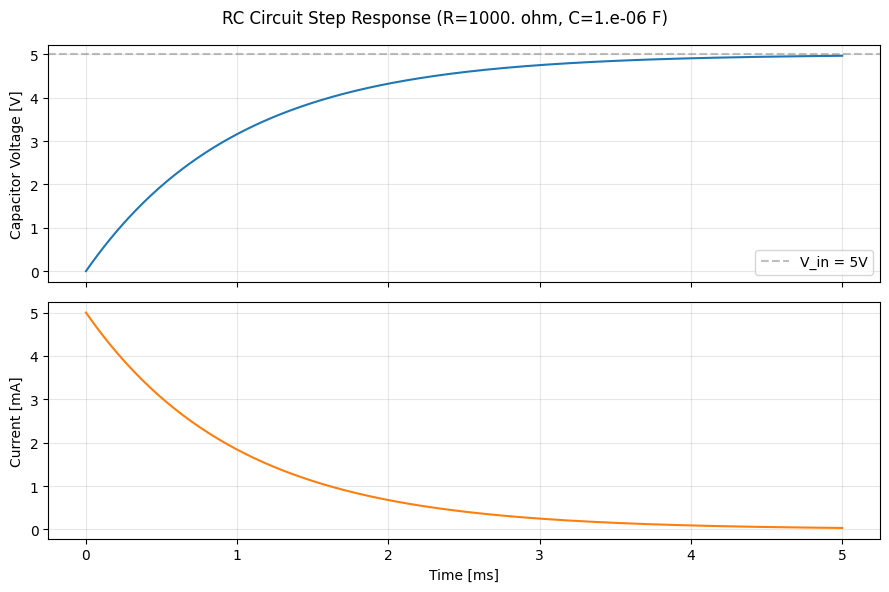

In [17]:
# RC circuit parameters
R = 1000.0 * u.ohm  # 1 kohm
C = 1e-6 * u.farad  # 1 uF
V_in = 5.0 * u.volt  # step input

# Time constant
tau = R * C  # ohm * farad = second
print('Time constant (tau):', tau)

# Time array
t = np.linspace(0.0, 5e-3, 500) * u.second

# Voltage across capacitor: V_C(t) = V_in * (1 - exp(-t/tau))
V_cap = V_in * (1 - np.exp(-t.to_decimal(u.second) / tau.to_decimal(u.second)))

# Current: I(t) = V_in/R * exp(-t/tau)
I = (V_in / R) * np.exp(-t.to_decimal(u.second) / tau.to_decimal(u.second))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(t.to_decimal(u.ms), V_cap.to_decimal(u.volt), color='tab:blue')
ax1.axhline(y=5.0, color='gray', linestyle='--', alpha=0.5, label='V_in = 5V')
ax1.set_ylabel('Capacitor Voltage [V]')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(t.to_decimal(u.ms), I.to_decimal(u.mA), color='tab:orange')
ax2.set_xlabel('Time [ms]')
ax2.set_ylabel('Current [mA]')
ax2.grid(alpha=0.3)

fig.suptitle(f'RC Circuit Step Response (R={R}, C={C})')
plt.tight_layout()
plt.show()

## How It Works

saiunit automatically registers a `QuantityConverter` with Matplotlib when imported.
This converter:

1. **Extracts numeric values** from `Quantity` objects via `.mantissa`
2. **Sets axis labels** from the unit's display name
3. **Handles unit conversion** if the axis already has a target unit

You can check whether the converter was registered:

In [18]:
from saiunit._matplotlib_compat import matplotlib_converter_registered

print('Matplotlib converter registered:', matplotlib_converter_registered)

Matplotlib converter registered: True


## Tips for Unit-Aware Plotting

| Approach | When to Use |
|----------|-------------|
| Pass `Quantity` directly | Auto axis labels, simple plots |
| `.to_decimal(unit)` | When you need plain arrays for colorbar, custom formatting |
| `.in_unit(unit)` | Convert to different unit, keep `Quantity` for plotting |
| `.to(unit)` | Same as `.in_unit()` |